This is the baseline model

Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42

Load Dataset

In [2]:
file_path = "../dataset/train_FD001.txt"

df = pd.read_csv(file_path, sep=r"\s+", header=None)

columns = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1,4)]
    + [f"sensor{i}" for i in range(1,22)]
)

df.columns = columns

df.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Dataset Overview

In [3]:
print("Shape:", df.shape)
print("Engines:", df["engine_id"].nunique())
print("Max Cycle:", df["cycle"].max())

df.describe()

Shape: (20631, 26)
Engines: 100
Max Cycle: 362


,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


Create RUL Target

In [4]:
max_cycle = df.groupby("engine_id")["cycle"].transform("max")

df["RUL"] = max_cycle - df["cycle"]

df.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


Clip RUL

In [5]:
df["RUL"] = df["RUL"].clip(upper=125)

Remove Engine ID

In [6]:
model_df = df.drop(columns=["engine_id"])

Feature Engineering

In [7]:
model_df["cycle_norm"] = model_df["cycle"] / model_df["cycle"].max()

In [8]:
for sensor in ["sensor7","sensor12","sensor15","sensor20"]:
    
    model_df[f"{sensor}_roll_mean"] = (
        model_df.groupby(df["engine_id"])[sensor]
        .rolling(5)
        .mean()
        .reset_index(level=0,drop=True)
    )

Handle Missing Values

In [9]:
model_df.bfill(inplace=True)

,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,...,sensor18,sensor19,sensor20,sensor21,RUL,cycle_norm,sensor7_roll_mean,sensor12_roll_mean,sensor15_roll_mean,sensor20_roll_mean
0,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,...,2388,100.0,39.06,23.4190,125,0.002762,554.164,522.282,8.41334,38.958
1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,...,2388,100.0,39.00,23.4236,125,0.005525,554.164,522.282,8.41334,38.958
2,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,...,2388,100.0,38.95,23.3442,125,0.008287,554.164,522.282,8.41334,38.958
3,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,...,2388,100.0,38.88,23.3739,125,0.011050,554.164,522.282,8.41334,38.958
4,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,...,2388,100.0,38.90,23.4044,125,0.013812,554.164,522.282,8.41334,38.958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,...,2388,100.0,38.49,22.9735,4,0.541436,551.604,519.890,8.52012,38.408
20627,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,...,2388,100.0,38.30,23.1594,3,0.544199,551.548,519.708,8.52506,38.356
20628,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,...,2388,100.0,38.44,22.9333,2,0.546961,551.328,519.688,8.52950,38.350
20629,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,...,2388,100.0,38.29,23.0640,1,0.549724,551.066,519.712,8.53298,38.332


Feature Selection

In [10]:
X = model_df.drop(columns=["RUL"])
y = model_df["RUL"]

selector = VarianceThreshold(threshold=0.01)

X = selector.fit_transform(X)

Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

Train Multiple Models

In [12]:
models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    )
}

Model Evaluation Function

In [13]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test,preds))
    mae = mean_absolute_error(y_test,preds)
    r2 = r2_score(y_test,preds)

    results.append([name,rmse,mae,r2])

results_df = pd.DataFrame(
    results,
    columns=["Model","RMSE","MAE","R2"]
)

results_df.sort_values("RMSE")

,Model,RMSE,MAE,R2
0,Random Forest,14.883075,9.815749,0.869436
2,XGBoost,15.317512,10.228233,0.861703
1,Gradient Boosting,15.709232,10.648686,0.854539


Best Model

In [14]:
best_model = models["XGBoost"]

best_model.fit(X_train,y_train)

predictions = best_model.predict(X_test)

Final Metrics

In [15]:
rmse = np.sqrt(mean_squared_error(y_test,predictions))
mae = mean_absolute_error(y_test,predictions)
r2 = r2_score(y_test,predictions)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 15.317512034490386
MAE: 10.228233337402344
R2: 0.8617027997970581


Scatter Plot (Actual vs Predicted)

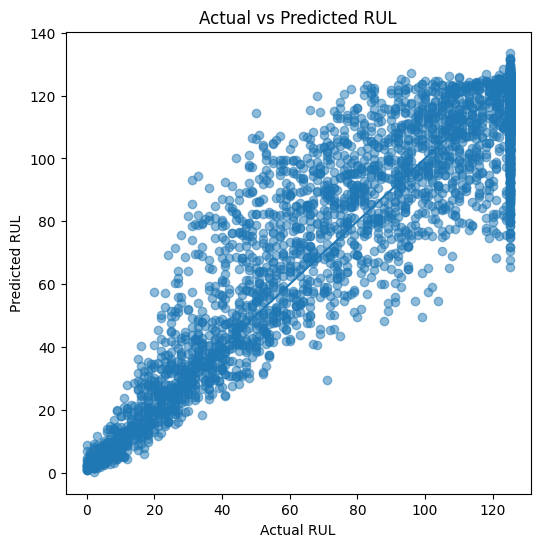

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,predictions,alpha=0.5)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

Model Stability (Cross Validation)

In [17]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R2:",scores)
print("Average R2:",scores.mean())

Cross Validation R2: [0.89249301 0.85995841 0.85341024 0.78626031 0.78587967]
Average R2: 0.8356003284454345


Feature Importance

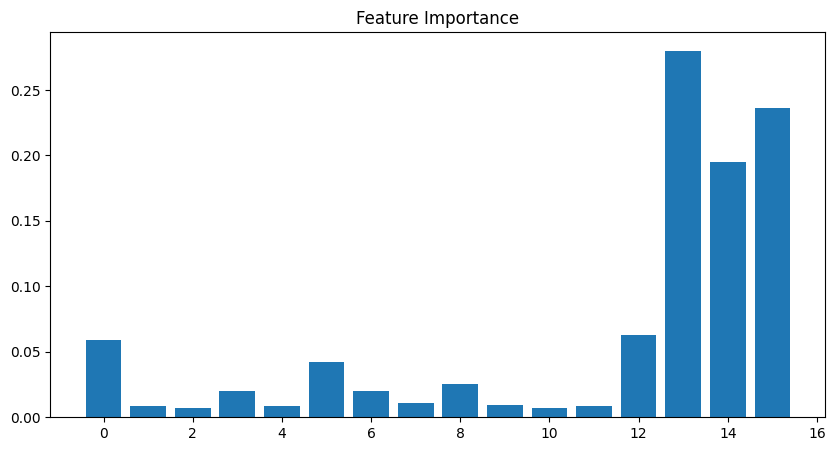

In [18]:
importances = best_model.feature_importances_

plt.figure(figsize=(10,5))

plt.bar(range(len(importances)),importances)

plt.title("Feature Importance")

plt.show()

Save Model

In [19]:
import joblib

joblib.dump({
    "model": best_model,
    "selector": selector
}, "rul_model.pkl")

['rul_model.pkl']